# Analysis and visualisation

### Installing libraries and importing modules

In [1]:
!pip install pandas
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

### ONS - General Health 2011 / 2021

#### Reading the cleaned data

In [2]:
census_health_sex = pd.read_csv("../data/clean/cleaned_census_health_sex.csv")
census_health_sex.head()

,year,country,health_status,sex,count,population,age_standardised_percentage,lower_95pct_confidence_interval,upper_95pct_confidence_interval
0,2021,England,Very good,Female,13653975,28833720,47.1,47.1,47.2
1,2021,England,Very good,Male,13736855,27656330,47.9,47.9,48.0
2,2021,England,Good,Female,9769630,28833720,34.2,34.1,34.2
3,2021,England,Good,Male,9271115,27656330,34.2,34.1,34.2
4,2021,England,Fair,Female,3807185,28833720,13.2,13.2,13.2


#### Health status by sex (2021)- How do men and women differ in self-reported health today?

In [3]:
# Filtering to 2021 DF
health_2021 = census_health_sex[census_health_sex["year"] == 2021]

In [4]:
# Prepping for visualisation

pivot_2021 = health_2021.pivot_table(
    index="health_status",
    columns="sex",
    values="age_standardised_percentage"
)

pivot_2021

sex,Female,Male
health_status,,
Bad,4.85,4.40
Fair,13.75,13.30
Good,33.35,33.40
Very bad,1.40,1.40
Very good,46.60,47.55


#### Self-Rated Health by sex

<Figure size 1000x600 with 0 Axes>

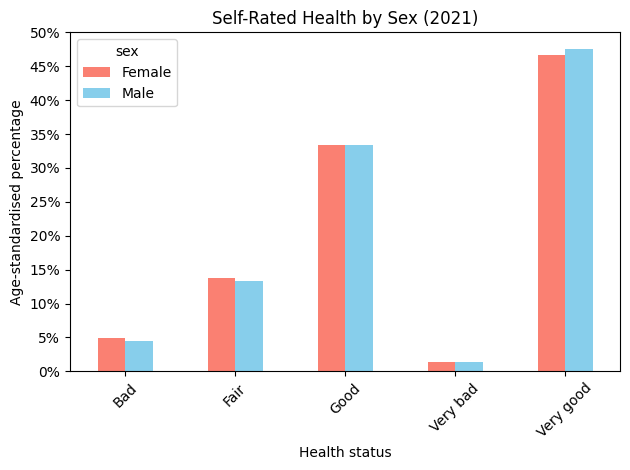

In [8]:
plt.figure(figsize=(10,6))

# Define your colors in a list
# Note: Ensure your columns are in the order [Male, Female] for the colors to match
my_colors = ['salmon', 'skyblue']

# Pass the 'color' argument inside the plot function
ax = pivot_2021.plot(kind="bar", color=my_colors)

# The rest of your styling remains exactly the same
ax.set_title("Self-Rated Health by Sex (2021)")
ax.set_xlabel("Health status")
ax.set_ylabel("Age-standardised percentage")
ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0f}%")

# Add more tick marks for readability
ax.set_yticks(range(0, 55, 5))  # 0%, 5%, 10%, ..., 50%

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Plot summary:**

- Most men and women report their health as either “Good” or “Very good”
- Men are slightly more likely to report “Very good” health than women
- Women are slightly more represented in the “Fair” and “Bad” categories
- The overall pattern is very similar between sexes, with only small differences across categories
- “Very bad” health is a very small proportion for both groups

**Interpretation (safe and accurate)**

- The data suggests subtle but measurable differences in how men and women rate their health
- These figures reflect population-level health patterns, not healthcare usage or cost
- The chart provides context, which may help explain differences later seen in NHS activity or spending data.

#### Change in 'Very Good' Self-Rated Health (2011-2021)

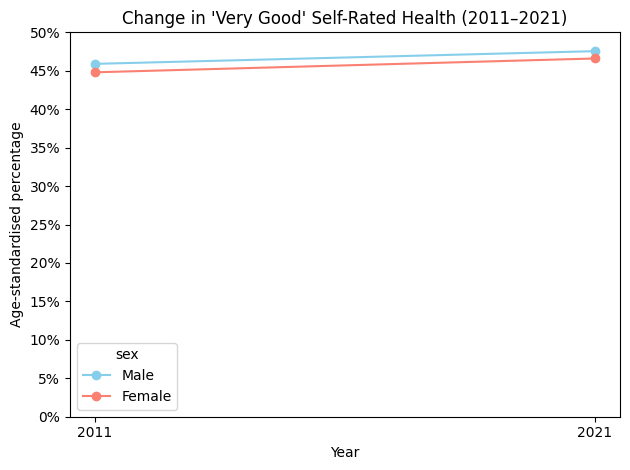

In [10]:
# Filtering to just the "Very good" category
very_good = census_health_sex[census_health_sex["health_status"] == "Very good"]

# Create a pivot table
pivot_vg = very_good.pivot_table(
    index="year",
    columns="sex",
    values="age_standardised_percentage"
)

# --- CRITICAL STEP FOR COLORS ---
# Reorder columns to ensure Male is first, then Female.
# This ensures Male gets 'skyblue' and Female gets 'salmon'
pivot_vg = pivot_vg[['Male', 'Female']]
my_colors = ['skyblue', 'salmon']

# Plot as a line chart with the specific colors
ax = pivot_vg.plot(marker="o", color=my_colors)

# Add titles and labels
ax.set_title("Change in 'Very Good' Self-Rated Health (2011–2021)")
ax.set_xlabel("Year")
ax.set_ylabel("Age-standardised percentage")

# Show years clearly on x-axis
plt.xticks([2011, 2021])

# Show more y-axis detail (every 5%)
ax.set_yticks(range(0, 55, 5))
ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0f}%")

# Clean layout
plt.tight_layout()
plt.show()

**Plot summary:**

- Both men and women report a small increase in “Very good” health over time
- Men consistently report slightly higher levels than women
- The difference between sexes has remained narrow and stable
- This indicates a broadly similar trend for both groups across the decade

#### Overall Health Profile by Sex (2021)

<Figure size 1000x600 with 0 Axes>

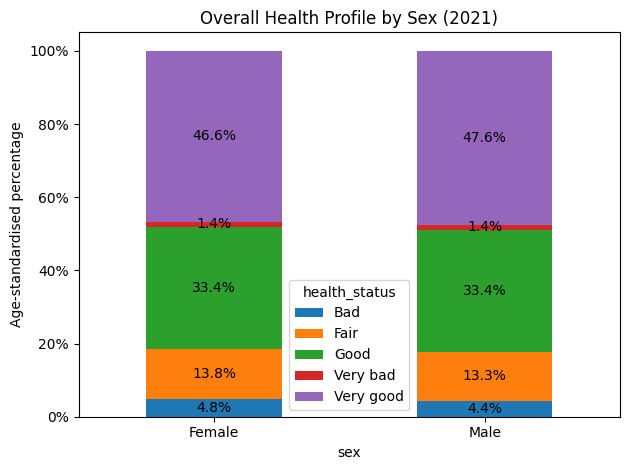

In [11]:
# Filtering to 2021 data
health_2021 = census_health_sex[census_health_sex["year"] == 2021]

# Pivoting for stacked bar
stacked = health_2021.pivot_table(
    index="sex",
    columns="health_status",
    values="age_standardised_percentage"
)

# Plotting
plt.figure(figsize=(10,6))
ax = stacked.plot(kind="bar", stacked=True)

# Axis formatting
ax.set_title("Overall Health Profile by Sex (2021)")
ax.set_ylabel("Age-standardised percentage")
ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0f}%")
plt.xticks(rotation=0)

# Adding % labels to each segment
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type="center")

plt.tight_layout()
plt.show()

**Plot summary:**

- Both genders are heavily concentrated in “Very good” and “Good” health categories
- Overall shape of the distribution is very similar for men and women
- Men show a slightly larger share in the “Very good” category
- Women show slightly higher representation in “Fair” and “Bad” categories
- The differences are present but not large in scale
- The stacked distribution shows that health outcomes are broadly similar between men and women. Minor differences exist, but there is no evidence of a major structural gap based on this dataset alone.

#### 10-Year trend: Percentage Reporting Poor Health (England)

In [12]:
df = census_health_sex

# Filtering to England (that's what we decided to focus on per the proposal) & grouping all bad results

df_england = df[df['country'] == 'England'].copy()
df_bad = df_england[df_england['health_status'].isin(['Bad', 'Very bad'])].copy()


# Calculating the %ges

trend_data = df_bad.groupby(['year', 'sex'])['age_standardised_percentage'].sum().reset_index()
pivot_trend = trend_data.pivot(index='year', columns='sex', values='age_standardised_percentage')

display(pivot_trend)

sex,Female,Male
year,,
2011,5.9,6.0
2021,5.5,5.1


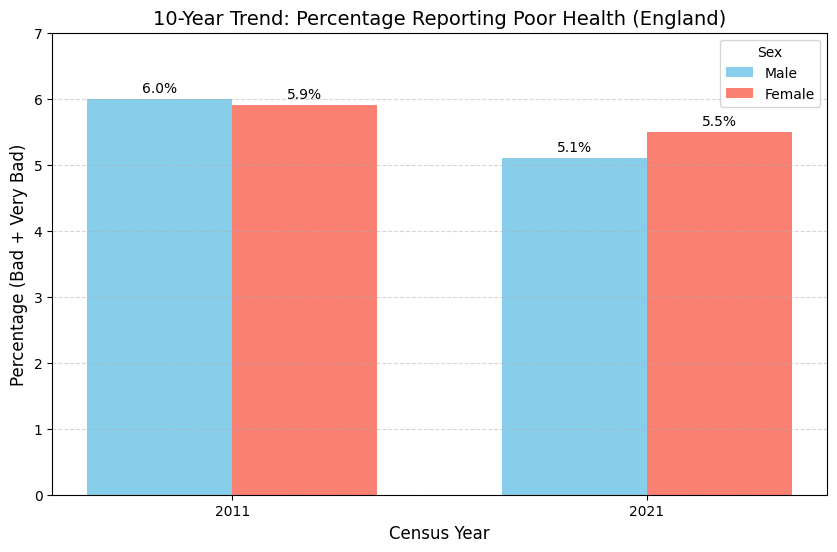

In [13]:
# Plotting

plt.figure(figsize=(10, 6))

years = pivot_trend.index  # [2011, 2021]
x_pos = np.arange(len(years))
width = 0.35


# Plotting Bars
plt.bar(x_pos - width/2, pivot_trend['Male'], width, label='Male', color='skyblue')
plt.bar(x_pos + width/2, pivot_trend['Female'], width, label='Female', color='salmon')


# Labels and Title
plt.title('10-Year Trend: Percentage Reporting Poor Health (England)', fontsize=14)
plt.ylabel('Percentage (Bad + Very Bad)', fontsize=12)
plt.xlabel('Census Year', fontsize=12)
plt.xticks(x_pos, years) # X-axis shows 2011 and 2021
plt.ylim(0, pivot_trend.max().max() + 1) # adding space


# Adding the numbers on top of the bars
for i, year in enumerate(years):
    # Male Label
    m_val = pivot_trend.loc[year, 'Male']
    plt.text(i - width/2, m_val + 0.1, f'{m_val:.1f}%', ha='center') # position of the text

    # Female Label
    f_val = pivot_trend.loc[year, 'Female']
    plt.text(i + width/2, f_val + 0.1, f'{f_val:.1f}%', ha='center')

plt.legend(title='Sex')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

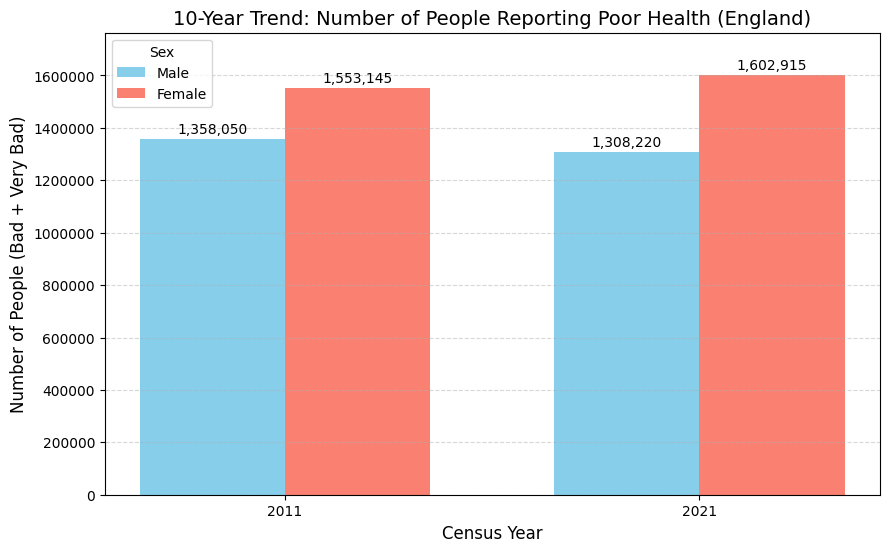

In [14]:
# same as above, but with numbers instead of percentages:


trend_data_counts = df_bad.groupby(['year', 'sex'])['count'].sum().reset_index()
pivot_trend_counts = trend_data_counts.pivot(index='year', columns='sex', values='count')

# display(pivot_trend_counts)


plt.figure(figsize=(10, 6))

years = pivot_trend_counts.index
x_pos = np.arange(len(years))
width = 0.35

# Plot Bars
plt.bar(x_pos - width/2, pivot_trend_counts['Male'], width, label='Male', color='skyblue')
plt.bar(x_pos + width/2, pivot_trend_counts['Female'], width, label='Female', color='salmon')

# Labels and Title
plt.title('10-Year Trend: Number of People Reporting Poor Health (England)', fontsize=14)
plt.ylabel('Number of People (Bad + Very Bad)', fontsize=12)
plt.xlabel('Census Year', fontsize=12)
plt.xticks(x_pos, years)
plt.ylim(0, pivot_trend_counts.max().max() * 1.1) # add 10% padding to the top
plt.ticklabel_format(style='plain', axis='y')

# Text Labels
for i, year in enumerate(years):
    # Male Label
    m_val = pivot_trend_counts.loc[year, 'Male']
    # Format as a whole number with a comma separator
    plt.text(i - width/2, m_val + 20000, f'{m_val:,.0f}', ha='center')

    # Female Label
    f_val = pivot_trend_counts.loc[year, 'Female']
    plt.text(i + width/2, f_val + 20000, f'{f_val:,.0f}', ha='center')

plt.legend(title='Sex')
plt.grid(axis='y', linestyle='--', alpha=0.5)

**Plots summary:**

- The percentage of both men and women reporting poor health decreased between 2011 and 2021, indicating an overall improvement in self-reported health in England
- Men saw a larger drop in the rate of poor health, decreasing by 0.9 percentage points (from 6.0% to 5.1%). Women's rate also improved, but by a smaller margin of 0.4 percentage points (from 5.9% to 5.5%)
- The data shows a flip in which gender reports a higher rate of poor health. In 2011, a slightly higher percentage of men reported poor health than women. By 2021, this reversed, with a slightly higher percentage of women reporting poor health
- Despite the percentage decrease, the absolute number of women reporting poor health actually rose slightly between 2011 and 2021 (from 1.55M to 1.60M). In contrast, the absolute number of men reporting poor health fell (from 1.36M to 1.31M)
- While England's overall health has improved on a percentage basis for both genders over the decade, the gains were more significant for men. The rising absolute number of women with poor health, despite a falling percentage, likely points to demographic factors like population growth and underscores that the total healthcare burden for this group may still be increasing



### Dataset 2

### Dataset 3